# DATA 230 · Homework 4

**Name:** Anees Saheba Guddi
**SJSU ID:** 018205330

**Textbook:** *Fundamentals of Data Visualization* — Claus O. Wilke
**Chapters covered:** 10 (Proportions) · 11 (Nested Proportions) · 12 (Associations) · 13 (Time Series)

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

plt.rcParams.update({"font.size": 11})
rng = np.random.default_rng(42)
print("Imports OK")

Imports OK


# Chapter 10 · Visualizing Proportions

**Core idea:** when we want to show how a whole is divided into parts, we need
visualizations that honestly encode *relative size*. Wilke covers:

- **Pie charts** — effective only with ≤4 large, distinct slices; angle perception is poor.
- **100 % stacked bars** — better for comparing composition across groups.
- **Side-by-side bars** — best for comparing individual proportions directly.
- **Waffle charts** — alternative that uses area in a grid, avoiding angle ambiguity.

## Ch 10 · Figure 1 — Pie Chart: When It Works vs When It Fails

Pie charts encode proportion as **angle** and **arc length**.
Humans compare lengths well, but angles poorly—especially when several slices are similar.

- **(a)** Four clearly distinct categories → readable.
- **(b)** Ten similar-sized categories → angles look nearly identical; ranking is impossible.

**Takeaway:** Reserve pie charts for ≤ 4–5 categories with meaningfully different sizes.

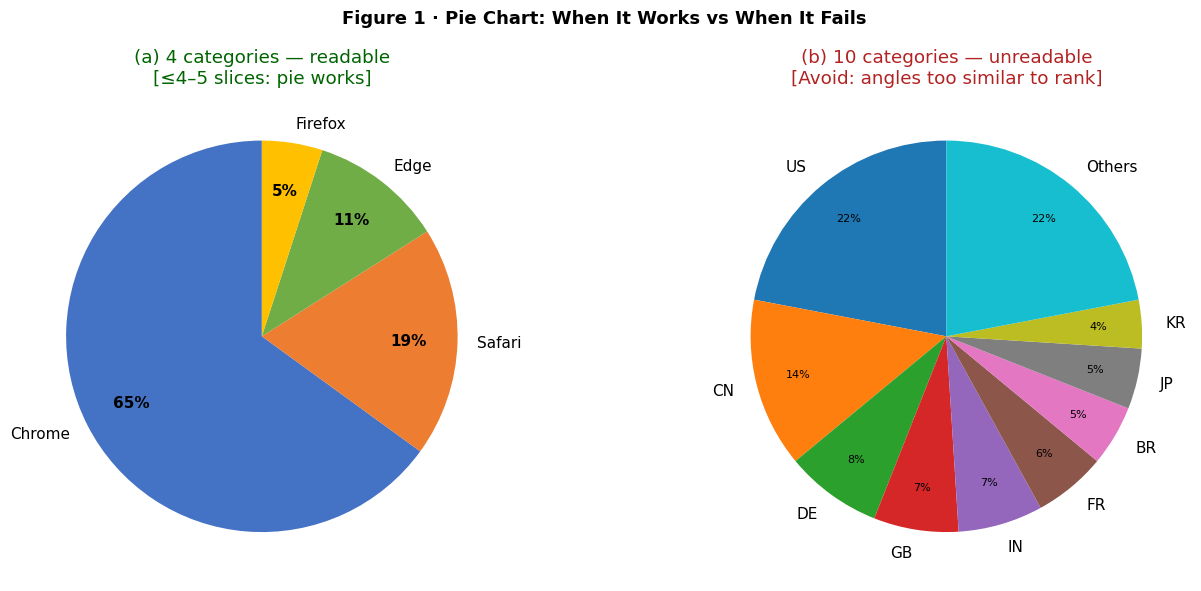

In [2]:
# Good case: 4 browser market-share categories
browsers   = ["Chrome", "Safari", "Edge", "Firefox"]
share_ok   = [65.0, 19.0, 11.0, 5.0]
colors_ok  = ["#4472C4", "#ED7D31", "#70AD47", "#FFC000"]

# Bad case: 10 nearly-equal categories
countries  = ["US","CN","DE","GB","IN","FR","BR","JP","KR","Others"]
web_traffic = [22, 14, 8, 7, 7, 6, 5, 5, 4, 22]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 1 · Pie Chart: When It Works vs When It Fails",
             fontsize=13, fontweight="bold")

wedges, texts, auts = ax1.pie(share_ok, labels=browsers, autopct="%1.0f%%",
                              colors=colors_ok, startangle=90, pctdistance=0.75)
for at in auts:
    at.set(fontsize=11, fontweight="bold")
ax1.set_title("(a) 4 categories — readable\n[≤4–5 slices: pie works]",
              color="darkgreen")

cmap10 = plt.cm.tab10
wedges2, texts2, auts2 = ax2.pie(
    web_traffic, labels=countries, autopct="%1.0f%%",
    colors=[cmap10(i) for i in range(len(countries))],
    startangle=90, pctdistance=0.78, labeldistance=1.12)
for at in auts2:
    at.set_fontsize(8)
ax2.set_title("(b) 10 categories — unreadable\n[Avoid: angles too similar to rank]",
              color="firebrick")

plt.tight_layout()
plt.savefig("ch10_fig1_pie_good_bad.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 10 · Figure 2 — Pie vs Stacked Bar: Same Data, Two Encodings

The 2021 German Bundestag results (actual seat counts) are shown as both a pie chart
and a horizontal stacked bar. The bar immediately reveals rank order; the pie requires
the reader to mentally compare arc lengths across a circle.

**Takeaway:** When ranking categories matters, bars beat pie every time.

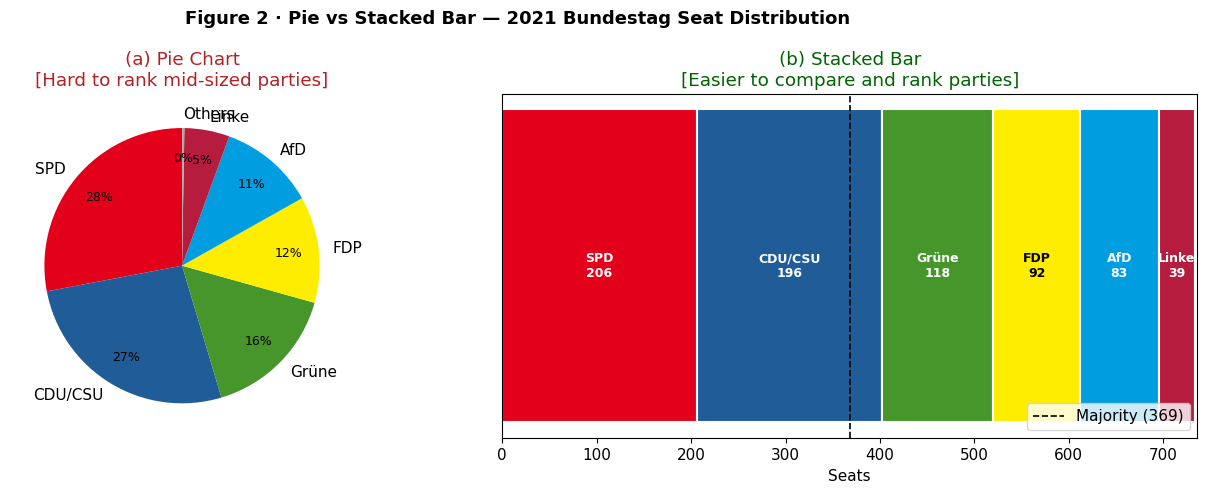

In [3]:
parties   = ["SPD", "CDU/CSU", "Grüne", "FDP", "AfD", "Linke", "Others"]
seats     = [206, 196, 118, 92, 83, 39, 2]
colors_bt = ["#E3001B","#1F5C98","#46962B","#FFED00","#009EE0","#B61C3E","#aaaaaa"]
total     = sum(seats)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 2 · Pie vs Stacked Bar — 2021 Bundestag Seat Distribution",
             fontsize=13, fontweight="bold")

# Pie
wedges, texts, auts = ax1.pie(seats, labels=parties, autopct="%1.0f%%",
                              colors=colors_bt, startangle=90, pctdistance=0.78)
for at in auts:
    at.set_fontsize(9)
ax1.set_title("(a) Pie Chart\n[Hard to rank mid-sized parties]", color="firebrick")

# Stacked bar
left = 0
for party, s, c in zip(parties, seats, colors_bt):
    ax2.barh(0, s, left=left, color=c, edgecolor="white", linewidth=1.5, height=0.5)
    if s > 15:
        txt_col = "white" if c != "#FFED00" else "black"
        ax2.text(left + s/2, 0, f"{party}\n{s}", ha="center", va="center",
                 fontsize=9, fontweight="bold", color=txt_col)
    left += s
ax2.axvline(total/2, color="black", linestyle="--", linewidth=1.2, label="Majority (369)")
ax2.set(xlim=(0, total), yticks=[], xlabel="Seats")
ax2.set_title("(b) Stacked Bar\n[Easier to compare and rank parties]", color="darkgreen")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.savefig("ch10_fig2_pie_vs_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 10 · Figure 3 — 100% Stacked Bar Chart

By normalizing each bar to 100 %, we can compare **composition** across groups
even when group totals are very different. This is ideal when the *relative*
breakdown matters more than the absolute count.

Here we compare Titanic survival rates across passenger classes.
The 1st-class survival advantage becomes immediately apparent.

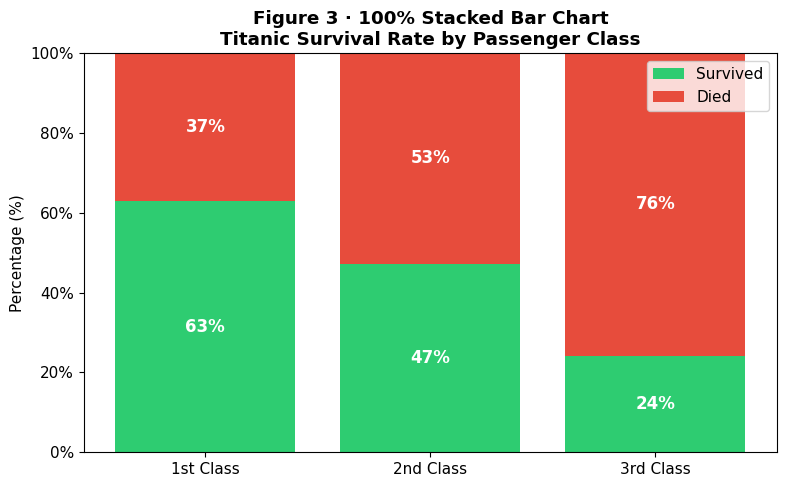

In [4]:
titanic = sns.load_dataset("titanic")

survival = (titanic.groupby(["pclass", "survived"])
            .size().unstack(fill_value=0)
            .rename(columns={0: "Died", 1: "Survived"}))
pct = survival.div(survival.sum(axis=1), axis=0) * 100

classes    = ["1st Class", "2nd Class", "3rd Class"]
surv_pct   = pct["Survived"].values
died_pct   = pct["Died"].values

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(classes, surv_pct, label="Survived", color="#2ecc71")
ax.bar(classes, died_pct, bottom=surv_pct, label="Died", color="#e74c3c")

for i, (sp, dp) in enumerate(zip(surv_pct, died_pct)):
    ax.text(i, sp/2,       f"{sp:.0f}%", ha="center", va="center",
            fontsize=12, fontweight="bold", color="white")
    ax.text(i, sp + dp/2,  f"{dp:.0f}%", ha="center", va="center",
            fontsize=12, fontweight="bold", color="white")

ax.set(ylim=(0,100), ylabel="Percentage (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.set_title("Figure 3 · 100% Stacked Bar Chart\n"
             "Titanic Survival Rate by Passenger Class", fontweight="bold")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig("ch10_fig3_stacked_100pct.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 10 · Figure 4 — Side-by-Side Proportional Bars

Side-by-side bars make **direct comparison** between sub-groups easy.
Unlike stacking, both the absolute bar height *and* the gap between bars are
visually decodable at the same time.

Here, survival rates are shown by both passenger class and sex simultaneously.
The gender gap is largest in 1st class (97 % female vs 37 % male).

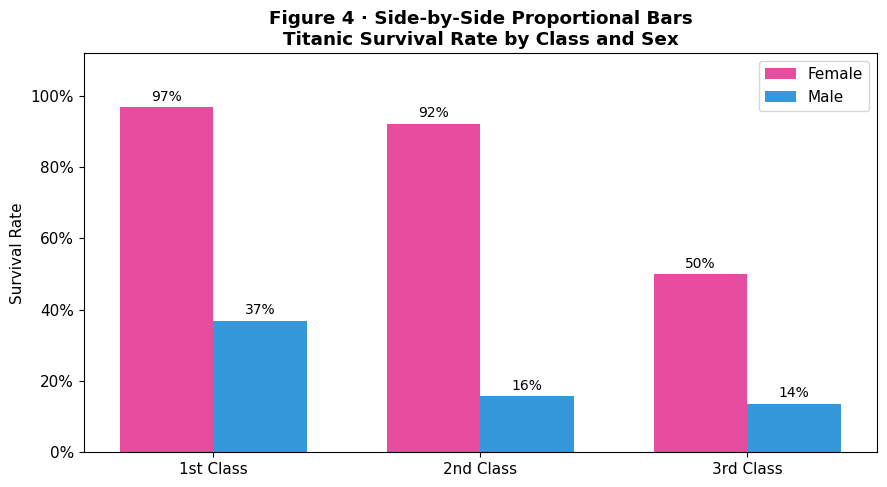

In [5]:
grp = (titanic.groupby(["sex","pclass"])["survived"]
       .mean().reset_index()
       .rename(columns={"survived":"rate"}))

x      = np.arange(3)
width  = 0.35
female = grp[grp.sex=="female"]["rate"].values
male   = grp[grp.sex=="male"]["rate"].values

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, female, width, label="Female", color="#e74c9e")
ax.bar(x + width/2, male,   width, label="Male",   color="#3498db")

for i, (f, m) in enumerate(zip(female, male)):
    ax.text(i - width/2, f + 0.01, f"{f:.0%}", ha="center", va="bottom", fontsize=10)
    ax.text(i + width/2, m + 0.01, f"{m:.0%}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])
ax.set(ylabel="Survival Rate", ylim=(0, 1.12))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax.set_title("Figure 4 · Side-by-Side Proportional Bars\n"
             "Titanic Survival Rate by Class and Sex", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("ch10_fig4_side_by_side_props.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 10 · Figure 5 — Waffle Chart

A **waffle chart** represents proportions as a 10×10 grid (each cell = 1 %).
It avoids the angle-comparison problem of pie charts and lets readers
*count* cells for precision. It works best when values are whole-number percentages.

Here we show US electricity generation by source—Natural Gas and Coal
together dominate more than half the grid.

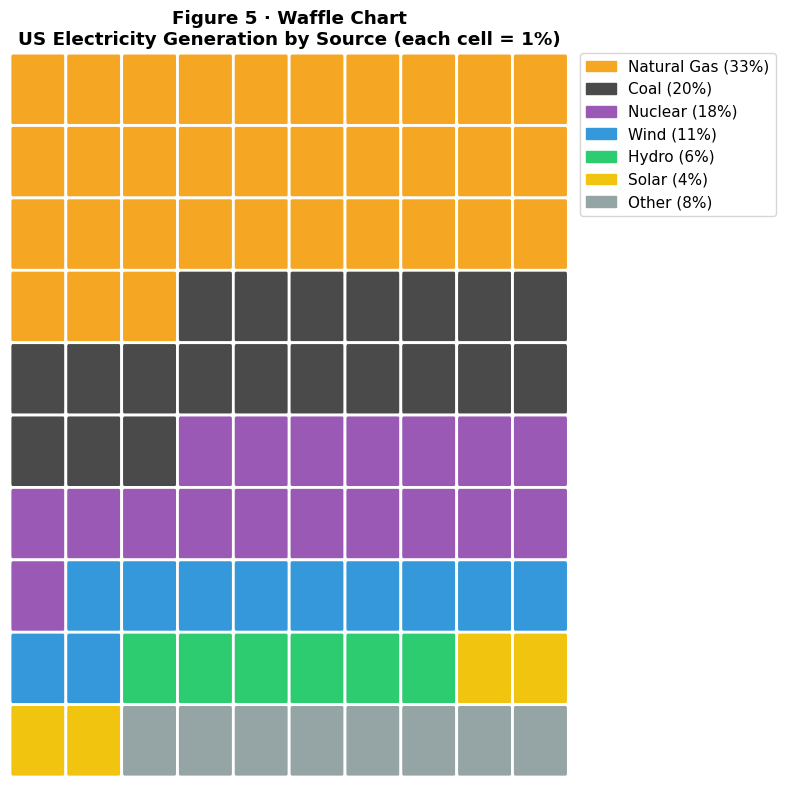

In [6]:
energy_sources = {
    "Natural Gas": 33, "Coal": 20, "Nuclear": 18,
    "Wind": 11, "Hydro": 6, "Solar": 4, "Other": 8,
}
energy_colors = {
    "Natural Gas": "#F5A623", "Coal": "#4A4A4A", "Nuclear": "#9B59B6",
    "Wind": "#3498DB", "Hydro": "#2ECC71", "Solar": "#F1C40F", "Other": "#95A5A6",
}

cells_list = []
for source, pct in energy_sources.items():
    cells_list.extend([source] * pct)
grid = np.array(cells_list[:100]).reshape(10, 10)

fig, ax = plt.subplots(figsize=(8, 8))
for row in range(10):
    for col in range(10):
        src = grid[row, col]
        rect = mpatches.FancyBboxPatch(
            (col + 0.05, 9 - row + 0.05), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=energy_colors[src], edgecolor="white", linewidth=2)
        ax.add_patch(rect)

patches = [mpatches.Patch(color=energy_colors[s], label=f"{s} ({v}%)")
           for s, v in energy_sources.items()]
ax.legend(handles=patches, loc="upper left",
          bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.set(xlim=(0,10), ylim=(0,10), xticks=[], yticks=[])
ax.spines[:].set_visible(False)
ax.set_title("Figure 5 · Waffle Chart\n"
             "US Electricity Generation by Source (each cell = 1%)", fontweight="bold")

plt.tight_layout()
plt.savefig("ch10_fig5_waffle.png", dpi=150, bbox_inches="tight")
plt.show()

## Chapter 10 · Key Findings

| Figure | Key insight |
|--------|-------------|
| 1 | Pie charts fail with ≥ 6 categories — angle discrimination breaks down. |
| 2 | Stacked bar beats pie for ranking: SPD barely leads CDU/CSU (206 vs 196 seats), which is invisible in the pie. |
| 3 | 100% stacked bar reveals that 1st-class Titanic passengers had a 63% survival rate vs only 24% in 3rd class. |
| 4 | Side-by-side bars make the gender gap explicit: female 1st-class survival was 97% vs 37% for males. |
| 5 | Waffle chart avoids the angle problem; counting cells gives precise percentages without mental arithmetic. |

# Chapter 11 · Visualizing Nested Proportions

**Core idea:** when categories themselves have sub-categories (a hierarchy),
we need visualizations that encode *both levels* simultaneously. Wilke covers:

- **Mosaic plots** — tile area encodes joint frequency of two categorical variables.
- **Treemaps** — nested rectangles for multi-level hierarchies.
- **Nested donuts** — generally discouraged; inner arc lengths are distorted.
- **Sunburst charts** — hierarchical pie; better than nested donut for two levels.
- **Parallel sets** — flow widths trace joint proportions across ≥ 3 categorical levels.

## Ch 11 · Figure 1 — Mosaic Plot

A mosaic plot encodes **two categorical dimensions at once**:
- **Width** of each column ∝ how many passengers were in that class.
- **Height** of the colored segment ∝ survival rate within that class.

This lets us see both "how common is each class?" and
"how deadly was each class?" in a single glance.

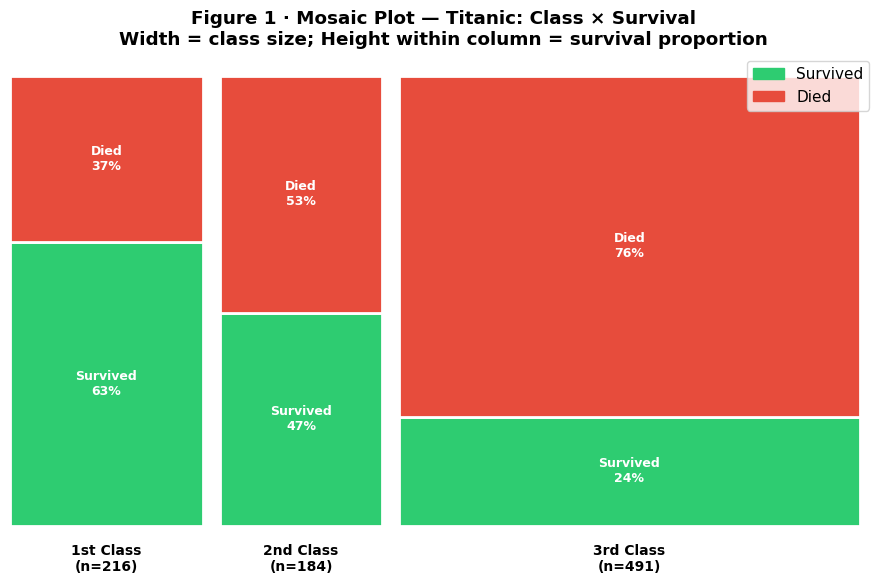

In [7]:
cross = (pd.crosstab(titanic["pclass"], titanic["survived"])
         .rename(columns={0:"Died",1:"Survived"},
                 index={1:"1st Class",2:"2nd Class",3:"3rd Class"}))
row_tot   = cross.sum(axis=1)
grand_tot = row_tot.sum()

fig, ax = plt.subplots(figsize=(9, 6))
gap = 0.02; x = 0.0

for cls in cross.index:
    n_cls = row_tot[cls]
    w = (n_cls / grand_tot) - gap
    s_h = cross.loc[cls, "Survived"] / n_cls   # survival proportion
    d_h = cross.loc[cls, "Died"]     / n_cls

    ax.add_patch(mpatches.Rectangle((x, 0),   w, s_h,
                 facecolor="#2ecc71", edgecolor="white", linewidth=2))
    ax.text(x+w/2, s_h/2, f"Survived\n{s_h:.0%}",
            ha="center", va="center", fontsize=9, fontweight="bold", color="white")

    ax.add_patch(mpatches.Rectangle((x, s_h), w, d_h,
                 facecolor="#e74c3c", edgecolor="white", linewidth=2))
    ax.text(x+w/2, s_h+d_h/2, f"Died\n{d_h:.0%}",
            ha="center", va="center", fontsize=9, fontweight="bold", color="white")

    ax.text(x+w/2, -0.04, f"{cls}\n(n={n_cls})",
            ha="center", va="top", fontsize=10, fontweight="bold")
    x += w + gap

ax.set(xlim=(0,1), ylim=(-0.1,1.05), xticks=[], yticks=[])
ax.spines[:].set_visible(False)
ax.set_title("Figure 1 · Mosaic Plot — Titanic: Class × Survival\n"
             "Width = class size; Height within column = survival proportion",
             fontweight="bold")
ax.legend(handles=[mpatches.Patch(color="#2ecc71", label="Survived"),
                    mpatches.Patch(color="#e74c3c", label="Died")],
          loc="upper right")

plt.tight_layout()
plt.savefig("ch11_fig1_mosaic.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 11 · Figure 2 — Treemap

A **treemap** uses nested rectangles to encode a hierarchy.
The area of each rectangle is proportional to its value.

- **Outer tiles** = world GDP by region (color coded).
- **Inner tiles** = country-level contribution within each region.

A single glance shows the US dominates globally and that Asia-Pacific
(China + Japan + India) rivals all of Europe combined.

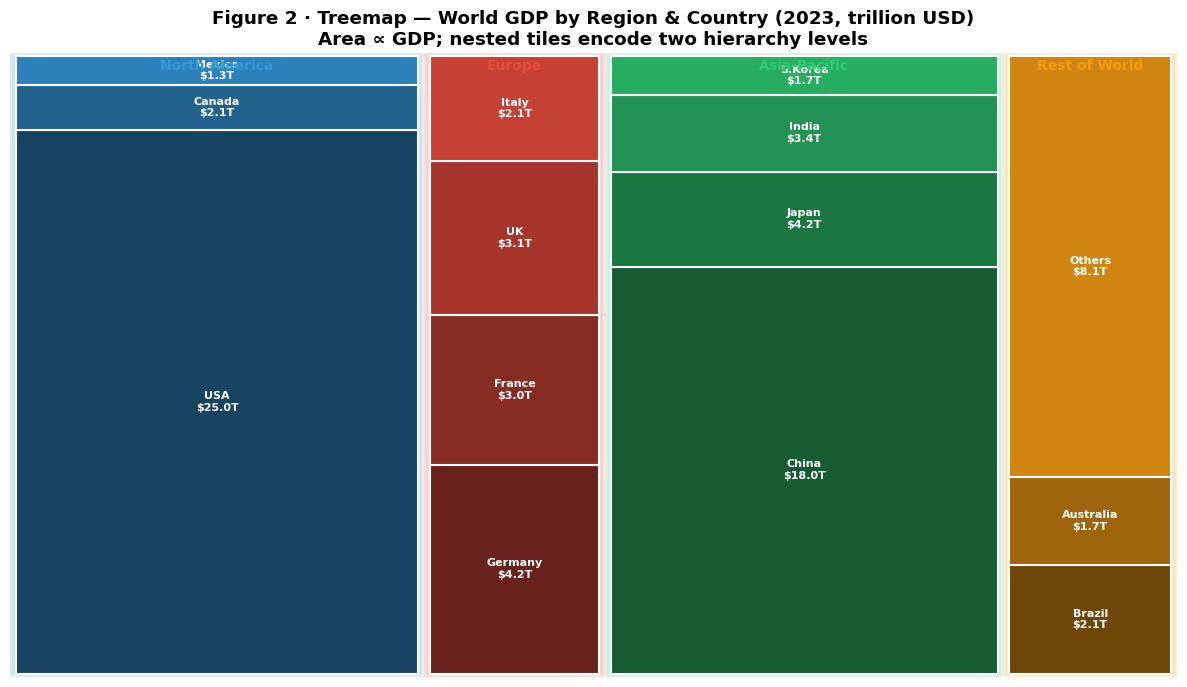

In [8]:
def slice_dice(values, labels, colors, x, y, w, h):
    rects = []
    total = sum(values)
    if total == 0:
        return rects
    if w >= h:
        cur = x
        for v, l, c in zip(values, labels, colors):
            rw = w * v / total
            rects.append(((cur, y, rw, h), l, v, c))
            cur += rw
    else:
        cur = y
        for v, l, c in zip(values, labels, colors):
            rh = h * v / total
            rects.append(((x, cur, w, rh), l, v, c))
            cur += rh
    return rects

gdp_data = {
    "North America": {"USA":25,"Canada":2.1,"Mexico":1.3},
    "Europe":        {"Germany":4.2,"France":3.0,"UK":3.1,"Italy":2.1},
    "Asia-Pacific":  {"China":18,"Japan":4.2,"India":3.4,"S.Korea":1.7},
    "Rest of World": {"Brazil":2.1,"Australia":1.7,"Others":8.1},
}
reg_colors = {"North America":"#3498DB","Europe":"#E74C3C",
              "Asia-Pacific":"#2ECC71","Rest of World":"#F39C12"}

reg_names  = list(gdp_data.keys())
reg_totals = [sum(gdp_data[r].values()) for r in reg_names]
reg_rects  = slice_dice(reg_totals, reg_names,
                        [reg_colors[r] for r in reg_names], 0, 0, 1, 1)

fig, ax = plt.subplots(figsize=(12, 7))
for (rx,ry,rw,rh), region, _, rcol in reg_rects:
    ax.add_patch(mpatches.Rectangle((rx,ry), rw, rh,
                 facecolor=rcol, edgecolor="white", linewidth=3, alpha=0.25))
    countries  = list(gdp_data[region].keys())
    cvals      = list(gdp_data[region].values())
    shades     = np.linspace(0.45, 0.85, len(countries))
    base       = mcolors.to_rgb(rcol)
    c_cols     = [tuple(min(1, s*x) for x in base) for s in shades]
    c_rects    = slice_dice(cvals, countries, c_cols,
                            rx+0.005, ry+0.005, rw-0.01, rh-0.01)
    for (cx,cy,cw,ch), ctry, cval, cc in c_rects:
        ax.add_patch(mpatches.Rectangle((cx,cy), cw, ch,
                     facecolor=cc, edgecolor="white", linewidth=1.5))
        if cw > 0.04 and ch > 0.04:
            ax.text(cx+cw/2, cy+ch/2, f"{ctry}\n${cval:.1f}T",
                    ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.text(rx+rw/2, ry+rh-0.01, region, ha="center", va="top",
            fontsize=10, fontweight="bold", color=rcol)

ax.set(xlim=(0,1), ylim=(0,1), xticks=[], yticks=[])
ax.spines[:].set_visible(False)
ax.set_title("Figure 2 · Treemap — World GDP by Region & Country (2023, trillion USD)\n"
             "Area ∝ GDP; nested tiles encode two hierarchy levels", fontweight="bold")
plt.tight_layout()
plt.savefig("ch11_fig2_treemap.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 11 · Figure 3 — Nested Donut: What NOT to Do vs Better Alternative

**Nested donuts** (concentric rings) seem intuitive for hierarchy, but they fail:
- The **inner ring** has a smaller circumference, so equal proportions appear smaller.
- Comparing segments *across* rings is essentially impossible.

The simple **horizontal bar chart** on the right shows the same sub-sector data
with immediately comparable bar lengths.

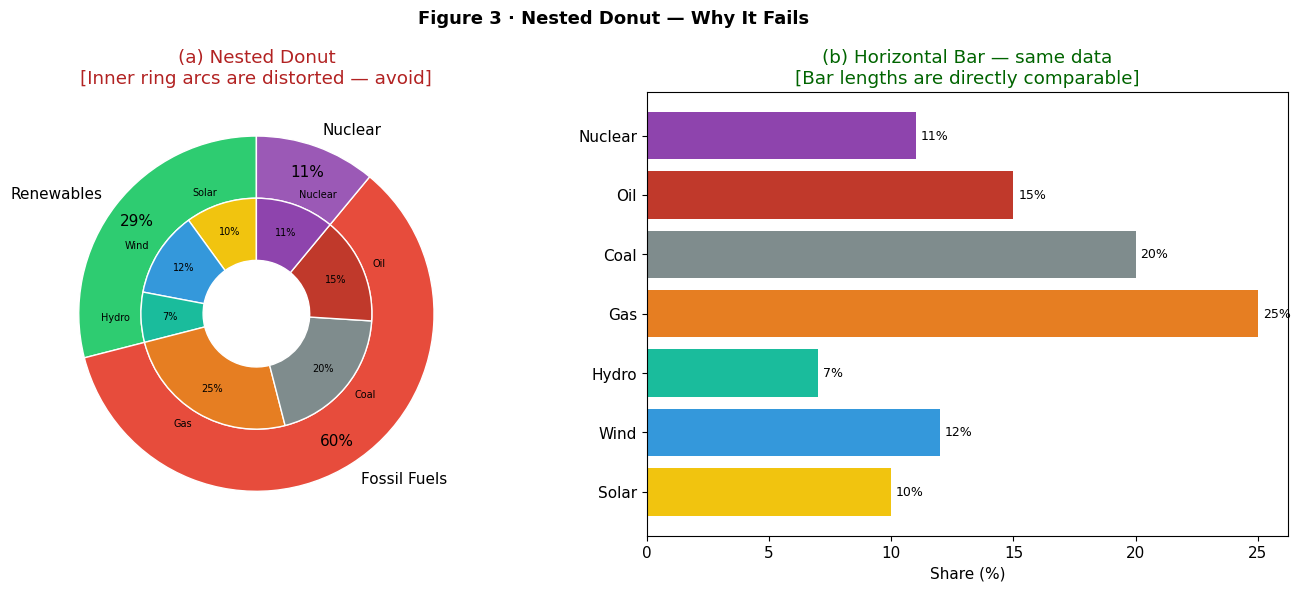

In [9]:
outer_labels = ["Renewables","Fossil Fuels","Nuclear"]
outer_sizes  = [29, 60, 11]
outer_colors = ["#2ECC71","#E74C3C","#9B59B6"]

inner_labels = ["Solar","Wind","Hydro","Gas","Coal","Oil","Nuclear"]
inner_sizes  = [10, 12, 7, 25, 20, 15, 11]
inner_colors = ["#F1C40F","#3498DB","#1ABC9C","#E67E22","#7F8C8D","#C0392B","#8E44AD"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Figure 3 · Nested Donut — Why It Fails", fontsize=13, fontweight="bold")

ax1.pie(outer_sizes, labels=outer_labels, colors=outer_colors,
        radius=1.0, wedgeprops=dict(width=0.35, edgecolor="white"),
        startangle=90, autopct="%1.0f%%", pctdistance=0.85)
ax1.pie(inner_sizes, labels=inner_labels, colors=inner_colors,
        radius=0.65, wedgeprops=dict(width=0.35, edgecolor="white"),
        startangle=90, autopct="%1.0f%%", pctdistance=0.75,
        textprops={"fontsize":7})
ax1.set_title("(a) Nested Donut\n[Inner ring arcs are distorted — avoid]",
              color="firebrick")

ax2.barh(inner_labels, inner_sizes, color=inner_colors)
ax2.set_xlabel("Share (%)")
ax2.set_title("(b) Horizontal Bar — same data\n[Bar lengths are directly comparable]",
              color="darkgreen")
for i, v in enumerate(inner_sizes):
    ax2.text(v+0.2, i, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ch11_fig3_nested_donut_bad.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 11 · Figure 4 — Sunburst Chart

A **sunburst chart** is a hierarchical pie: the inner ring encodes the first level
and the outer ring encodes the second level. It is more readable than a nested donut
because the outer ring's arc length is largest and thus easiest to compare.

Here we visualize global CO₂ emissions by sector and sub-sector.
The **Energy sector** dominates (≈ 51 %), with electricity generation alone
accounting for 25 % of all global emissions.

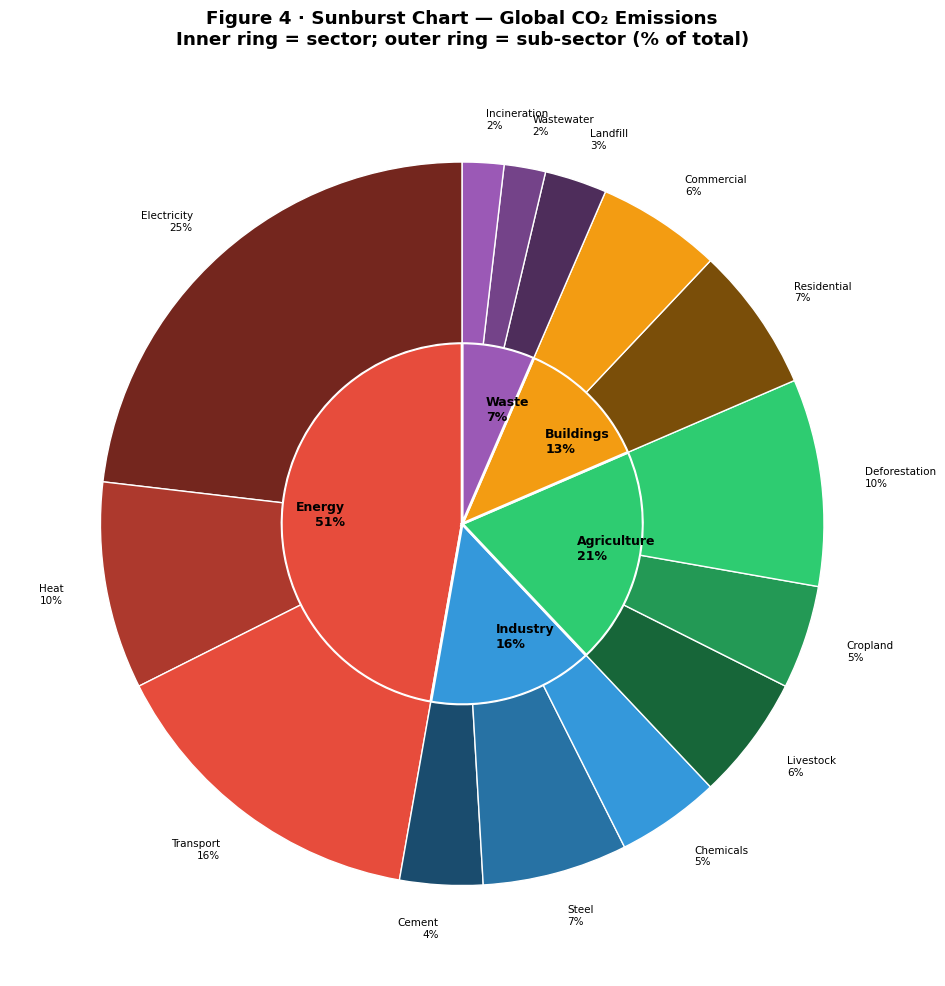

In [10]:
sectors = {
    "Energy":      {"Electricity":25,"Heat":10,"Transport":16},
    "Industry":    {"Cement":4,"Steel":7,"Chemicals":5},
    "Agriculture": {"Livestock":6,"Cropland":5,"Deforestation":10},
    "Buildings":   {"Residential":7,"Commercial":6},
    "Waste":       {"Landfill":3,"Wastewater":2,"Incineration":2},
}
sec_colors = {"Energy":"#E74C3C","Industry":"#3498DB","Agriculture":"#2ECC71",
              "Buildings":"#F39C12","Waste":"#9B59B6"}

inner_v, inner_l, inner_c = [], [], []
outer_v, outer_l, outer_c = [], [], []

for sec, subs in sectors.items():
    sc = sec_colors[sec]
    tot = sum(subs.values())
    inner_v.append(tot); inner_l.append(f"{sec}\n{tot}%"); inner_c.append(sc)
    n = len(subs)
    for i, (sub, val) in enumerate(subs.items()):
        outer_v.append(val); outer_l.append(f"{sub}\n{val}%")
        shade = 0.5 + 0.5*(i/max(n-1,1))
        outer_c.append(tuple(min(1, x*shade) for x in mcolors.to_rgb(sc)))

fig, ax = plt.subplots(figsize=(10,10))
ax.pie(inner_v, labels=inner_l, colors=inner_c, radius=0.5,
       wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
       startangle=90, labeldistance=0.65,
       textprops={"fontsize":9,"fontweight":"bold"})
ax.pie(outer_v, labels=outer_l, colors=outer_c, radius=1.0,
       wedgeprops=dict(width=0.5, edgecolor="white", linewidth=1),
       startangle=90, labeldistance=1.12,
       textprops={"fontsize":7.5})
ax.set_title("Figure 4 · Sunburst Chart — Global CO₂ Emissions\n"
             "Inner ring = sector; outer ring = sub-sector (% of total)",
             fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("ch11_fig4_sunburst.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 11 · Figure 5 — Parallel Sets

**Parallel sets** visualize how a dataset flows across multiple categorical levels.
Each vertical bar represents one level; ribbon widths are proportional to
the number of observations with that combination.

For Titanic data (Class → Sex → Outcome):
- Wide green ribbons from female → Survived confirm women were prioritized.
- Male 3rd-class passengers have almost no green ribbon — very few survived.

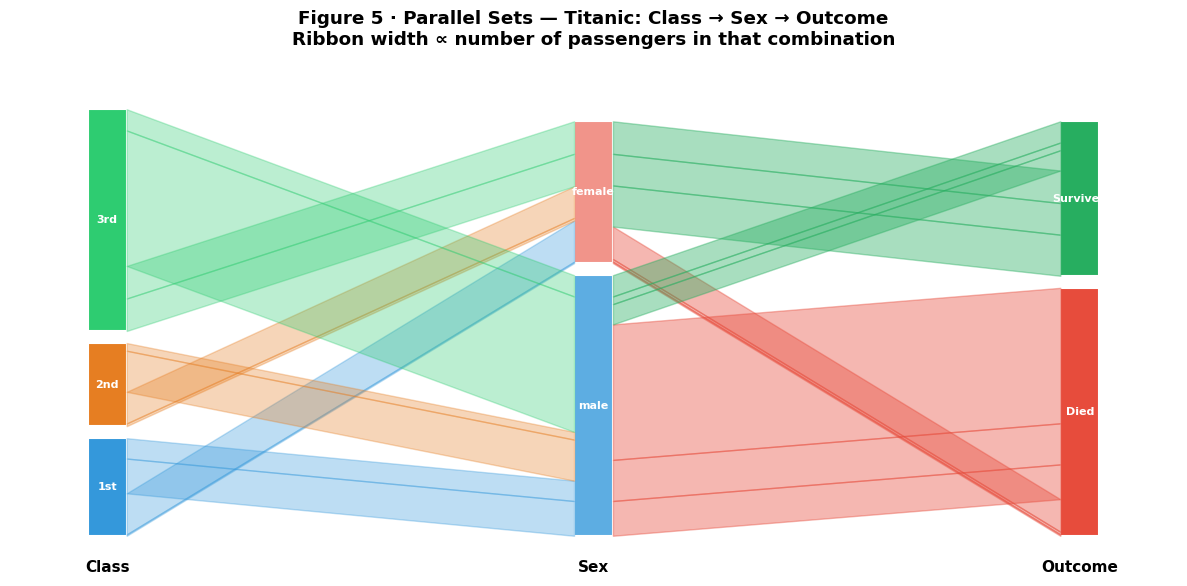

In [11]:
ct = (titanic.groupby(["pclass","sex","survived"])
      .size().reset_index(name="count"))
ct["cls"] = ct["pclass"].map({1:"1st",2:"2nd",3:"3rd"})
ct["out"] = ct["survived"].map({0:"Died",1:"Survived"})
total     = ct["count"].sum()

# Palette
col = {"1st":"#3498DB","2nd":"#E67E22","3rd":"#2ECC71",
       "male":"#5DADE2","female":"#F1948A",
       "Died":"#E74C3C","Survived":"#27AE60"}

level_cats = [
    (0, ["1st","2nd","3rd"]),
    (1, ["male","female"]),
    (2, ["Died","Survived"]),
]
level_names = ["Class","Sex","Outcome"]
GAP = 0.03

# Aggregate per level
lev_counts = [{}, {}, {}]
for r in ct.itertuples():
    lev_counts[0][r.cls] = lev_counts[0].get(r.cls,0) + r.count
    lev_counts[1][r.sex] = lev_counts[1].get(r.sex,0) + r.count
    lev_counts[2][r.out] = lev_counts[2].get(r.out,0) + r.count

def extents(cats, counts, total, lx):
    out = {}; y = 0
    for c in cats:
        h = counts.get(c,0)/total
        out[c] = (y, y+h, lx)
        y += h + GAP
    return out

exts = [extents(cats, lev_counts[i], total, i)
        for i, (_, cats) in enumerate(level_cats)]

fig, ax = plt.subplots(figsize=(12,6))
BW = 0.08

# Draw bars and labels
for lev_i, (lx, cats) in enumerate(level_cats):
    for cat in cats:
        y0, y1, _ = exts[lev_i][cat]
        ax.add_patch(mpatches.Rectangle((lx-BW/2, y0), BW, y1-y0,
                     facecolor=col[cat], edgecolor="white", linewidth=1.5))
        ax.text(lx, (y0+y1)/2, cat, ha="center", va="center",
                fontsize=8, fontweight="bold", color="white")
    ax.text(lx, -0.06, level_names[lev_i],
            ha="center", va="top", fontsize=11, fontweight="bold")

# Class → Sex ribbons
off_l = {c: exts[0][c][0] for c in ["1st","2nd","3rd"]}
off_r = {c: exts[1][c][0] for c in ["male","female"]}
for r in ct.sort_values(["cls","sex"]).itertuples():
    w = r.count/total
    x0, x1 = 0+BW/2, 1-BW/2
    tvals = np.linspace(0,1,50)
    bx  = x0 + (x1-x0)*tvals
    by0 = off_l[r.cls] + (off_r[r.sex] - off_l[r.cls])*tvals
    by1 = by0 + w
    ax.fill_between(bx, by0, by1, color=col[r.cls], alpha=0.32)
    off_l[r.cls] += w; off_r[r.sex] += w

# Sex → Outcome ribbons
off_l2 = {c: exts[1][c][0] for c in ["male","female"]}
off_r2 = {c: exts[2][c][0] for c in ["Died","Survived"]}
for r in ct.sort_values(["sex","out"]).itertuples():
    w = r.count/total
    x0, x1 = 1+BW/2, 2-BW/2
    tvals = np.linspace(0,1,50)
    bx  = x0 + (x1-x0)*tvals
    by0 = off_l2[r.sex] + (off_r2[r.out]-off_l2[r.sex])*tvals
    by1 = by0 + w
    ax.fill_between(bx, by0, by1, color=col[r.out], alpha=0.4)
    off_l2[r.sex] += w; off_r2[r.out] += w

ax.set(xlim=(-0.2,2.2), ylim=(-0.1,1.2), xticks=[], yticks=[])
ax.spines[:].set_visible(False)
ax.set_title("Figure 5 · Parallel Sets — Titanic: Class → Sex → Outcome\n"
             "Ribbon width ∝ number of passengers in that combination",
             fontweight="bold")
plt.tight_layout()
plt.savefig("ch11_fig5_parallel_sets.png", dpi=150, bbox_inches="tight")
plt.show()

## Chapter 11 · Key Findings

| Figure | Key insight |
|--------|-------------|
| 1 | Mosaic plot shows 3rd class was the *largest* class but had the *lowest* survival rate (24%), while 1st class (small width) had 63% survival. |
| 2 | Treemap makes it visually obvious: USA's tile alone is larger than the entire European region combined. |
| 3 | Nested donuts distort inner arcs—the 10% Solar inner slice looks *smaller* than it should. Bars fix this instantly. |
| 4 | Sunburst chart reveals Energy dominates CO₂ emissions (51%), with Electricity and Transport being the two biggest sub-sectors. |
| 5 | Parallel sets show female passengers had wide green "Survived" ribbons at all classes; male 3rd-class passengers had almost no green ribbon. |

# Chapter 12 · Visualizing Associations Among Two or More Quantitative Variables

**Core idea:** to reveal relationships between continuous variables we need charts
that let us see both individual observations and overall trends. Wilke covers:

- **Scatter plots** — the fundamental tool; encode two variables as x/y position.
- **Smoothing lines** — OLS, LOESS, or moving average to highlight the trend.
- **Bubble charts** — encode a third variable as circle area.
- **Scatter plot matrix** — all pairwise scatter plots in a grid.
- **Correlograms** — compact heatmap of pairwise correlations.
- **2-D histograms / hexbins** — handle overplotting in large datasets.

## Ch 12 · Figure 1 — Scatter Plot with OLS Trend Line

A scatter plot places one variable on each axis; each point is one observation.
Adding an **OLS (ordinary least squares) regression line** makes the trend explicit.

**Vehicle weight vs. fuel efficiency (Auto MPG dataset):** the strong negative
relationship (r ≈ −0.83) means heavier cars consume significantly more fuel.
The line translates the slope to "each extra 1,000 lbs ≈ −7 mpg."

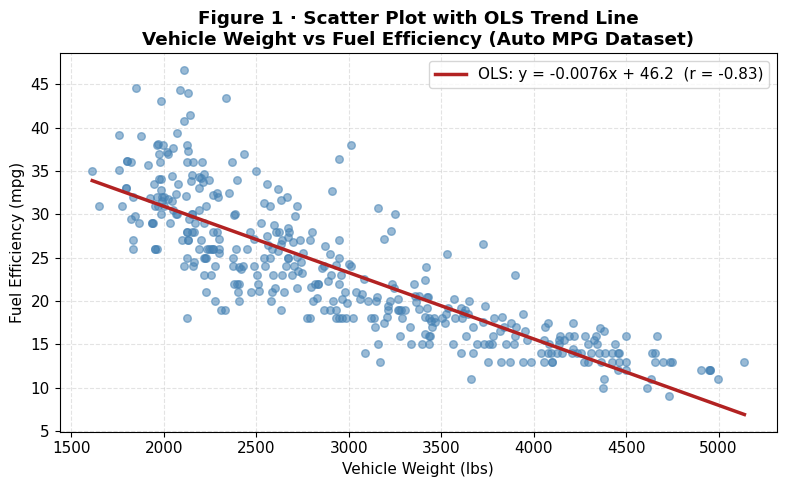

In [12]:
mpg = sns.load_dataset("mpg").dropna()
slope, intercept, r, p, se = stats.linregress(mpg["weight"], mpg["mpg"])
x_fit = np.linspace(mpg["weight"].min(), mpg["weight"].max(), 200)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(mpg["weight"], mpg["mpg"], color="steelblue", alpha=0.55, s=30, zorder=2)
ax.plot(x_fit, y_fit, color="firebrick", linewidth=2.5,
        label=f"OLS: y = {slope:.4f}x + {intercept:.1f}  (r = {r:.2f})")
ax.set(xlabel="Vehicle Weight (lbs)", ylabel="Fuel Efficiency (mpg)")
ax.set_title("Figure 1 · Scatter Plot with OLS Trend Line\n"
             "Vehicle Weight vs Fuel Efficiency (Auto MPG Dataset)",
             fontweight="bold")
ax.legend()
ax.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("ch12_fig1_scatter_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 12 · Figure 2 — Overplotting: Three Fixes

When many points land in the same region, **overplotting** hides density.
Three progressively better solutions:

- **(a) Opaque dots** — severe overplotting; can't tell if 5 or 500 points overlap.
- **(b) Alpha transparency** — shade intensity reveals density.
- **(c) Transparency + KDE contours** — best: shows *both* raw data distribution
  and the density peaks without ambiguity.

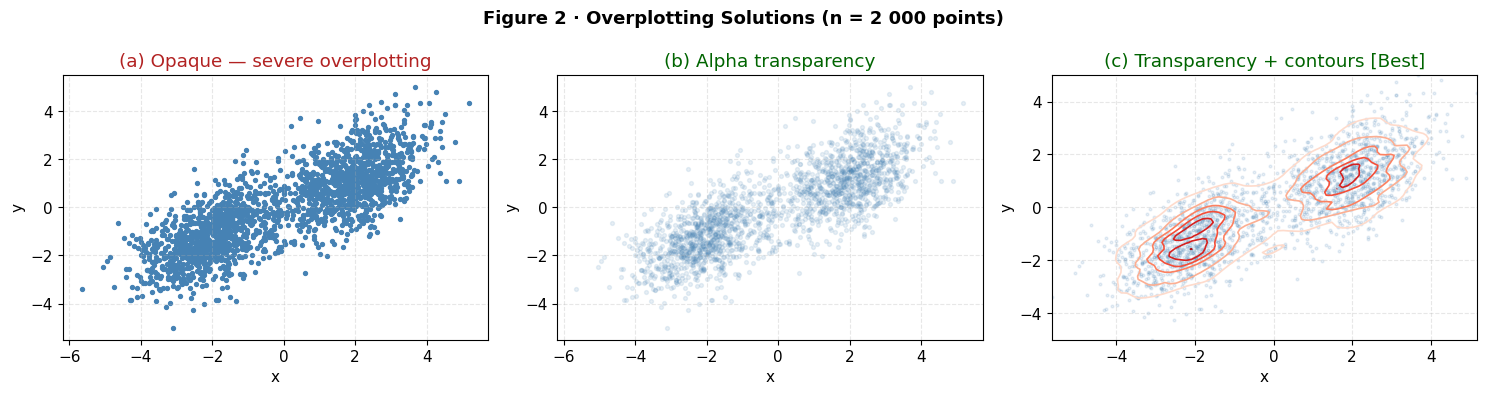

In [13]:
n = 2000
x_dense = rng.normal(0, 1, n) + rng.choice([-2, 2], n)
y_dense = 0.6 * x_dense + rng.normal(0, 1, n)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Figure 2 · Overplotting Solutions (n = 2 000 points)",
             fontsize=13, fontweight="bold")

a1.scatter(x_dense, y_dense, s=8, color="steelblue")
a1.set_title("(a) Opaque — severe overplotting", color="firebrick")

a2.scatter(x_dense, y_dense, s=8, color="steelblue", alpha=0.12)
a2.set_title("(b) Alpha transparency", color="darkgreen")

a3.scatter(x_dense, y_dense, s=4, color="steelblue", alpha=0.12)
xy   = np.vstack([x_dense, y_dense])
kde  = gaussian_kde(xy, bw_method=0.15)
xi, yi = np.mgrid[x_dense.min():x_dense.max():80j,
                   y_dense.min():y_dense.max():80j]
zi   = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape)
a3.contour(xi, yi, zi, levels=6, cmap="Reds", linewidths=1.2)
a3.set_title("(c) Transparency + contours [Best]", color="darkgreen")

for ax in (a1, a2, a3):
    ax.set(xlabel="x", ylabel="y")
    ax.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("ch12_fig2_overplotting.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 12 · Figure 3 — Bubble Chart (Gapminder-style)

A **bubble chart** extends scatter to a third quantitative variable encoded as
circle **area** (not radius—area is perceptually proportional to value).
Color maps a fourth, categorical variable (continent).

**Key rule from Wilke:** always scale area, never radius.
Using radius would make large bubbles appear disproportionately bigger.

The log-scale x-axis reveals an S-shaped relationship: life expectancy grows
steeply from $500–$15,000 GDP/capita, then flattens—returns to health
diminish at high income.

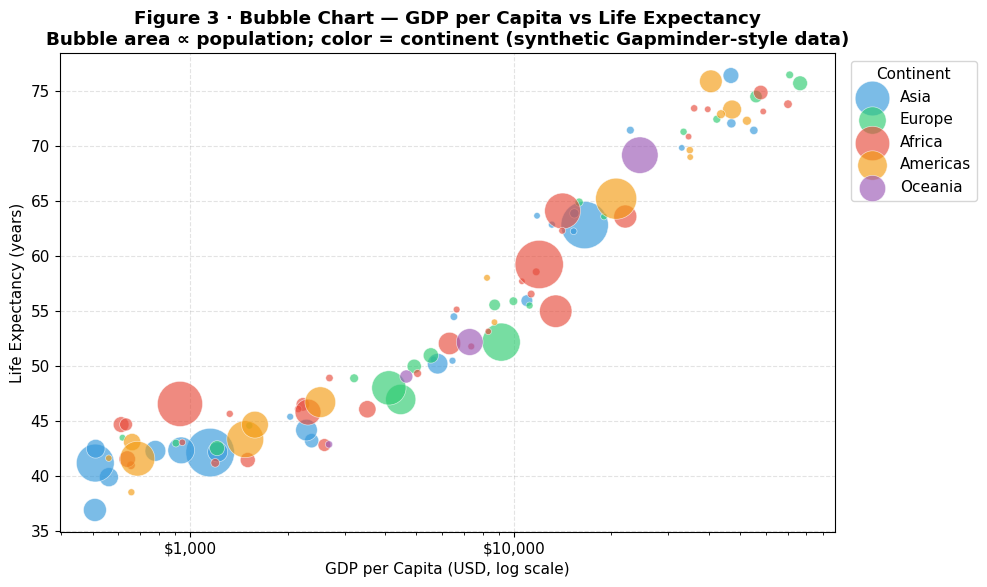

In [14]:
# Synthetic Gapminder-style country data
n_c = 100
gdp    = np.exp(rng.uniform(np.log(500), np.log(80_000), n_c))
life   = 40 + 35*(1 - np.exp(-gdp/15_000)) + rng.normal(0, 2, n_c)
pop    = np.exp(rng.uniform(np.log(1), np.log(1400), n_c))
conts  = rng.choice(["Africa","Asia","Europe","Americas","Oceania"],
                     p=[0.30,0.30,0.20,0.15,0.05], size=n_c)
df_gap = pd.DataFrame({"gdp":gdp,"life":life,"pop":pop,"continent":conts})
cont_c = {"Africa":"#E74C3C","Asia":"#3498DB","Europe":"#2ECC71",
           "Americas":"#F39C12","Oceania":"#9B59B6"}

fig, ax = plt.subplots(figsize=(10, 6))
for cont in df_gap["continent"].unique():
    sub = df_gap[df_gap.continent == cont]
    sizes = 20 + (sub["pop"]/df_gap["pop"].max())*1200
    ax.scatter(sub["gdp"], sub["life"], s=sizes,
               color=cont_c[cont], alpha=0.65, edgecolors="white",
               linewidths=0.5, label=cont, zorder=3)

ax.set_xscale("log")
ax.set(xlabel="GDP per Capita (USD, log scale)", ylabel="Life Expectancy (years)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda v,_: f"${v:,.0f}" if v>=1000 else f"${v:.0f}"))
ax.set_title("Figure 3 · Bubble Chart — GDP per Capita vs Life Expectancy\n"
             "Bubble area ∝ population; color = continent (synthetic Gapminder-style data)",
             fontweight="bold")
ax.legend(title="Continent", bbox_to_anchor=(1.01,1), loc="upper left")
ax.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("ch12_fig3_bubble.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 12 · Figure 4 — Scatter Plot Matrix (Pair Plot)

A **pair plot** shows all pairwise scatter plots for a set of variables
in a grid. The diagonal shows each variable's own distribution.
Color encodes a categorical grouping variable (Iris species).

**Key finding:** petal dimensions (length and width) perfectly separate
the three Iris species, while sepal dimensions have heavy overlap
between versicolor and virginica—important for feature selection in ML.

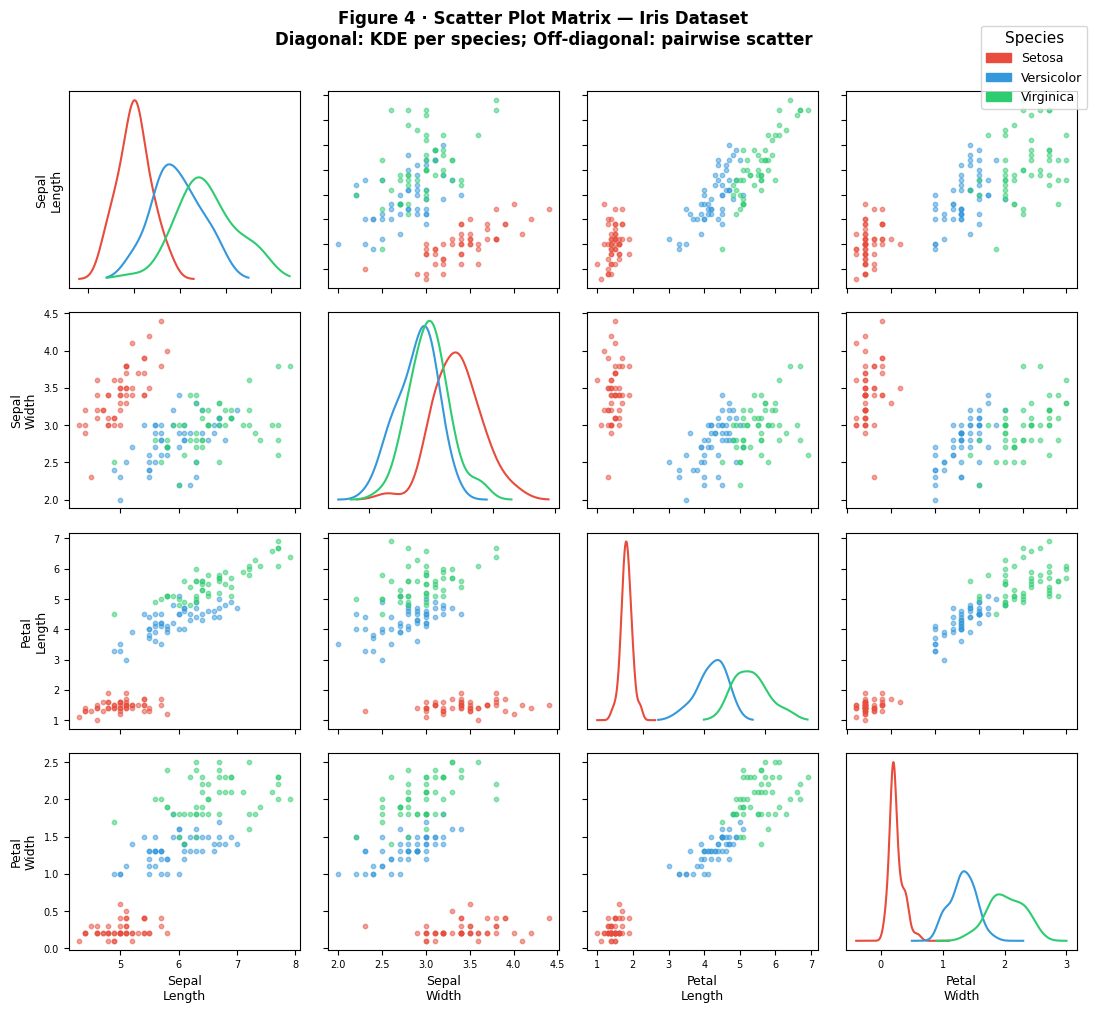

In [15]:
iris     = sns.load_dataset("iris")
features = ["sepal_length","sepal_width","petal_length","petal_width"]
labels_f = ["Sepal\nLength","Sepal\nWidth","Petal\nLength","Petal\nWidth"]
species  = iris["species"].unique()
sp_c     = {"setosa":"#E74C3C","versicolor":"#3498DB","virginica":"#2ECC71"}
n        = len(features)

fig, axes = plt.subplots(n, n, figsize=(11, 10))
fig.suptitle("Figure 4 · Scatter Plot Matrix — Iris Dataset\n"
             "Diagonal: KDE per species; Off-diagonal: pairwise scatter",
             fontsize=12, fontweight="bold", y=1.01)

for i, fi in enumerate(features):
    for j, fj in enumerate(features):
        ax = axes[i, j]
        if i == j:
            for sp in species:
                d = iris.loc[iris.species==sp, fi].values
                kde = gaussian_kde(d, bw_method=0.5)
                xs  = np.linspace(d.min()-0.5, d.max()+0.5, 200)
                ax.plot(xs, kde(xs), color=sp_c[sp], linewidth=1.5)
            ax.set_yticks([])
        else:
            for sp in species:
                sub = iris[iris.species==sp]
                ax.scatter(sub[fj], sub[fi], color=sp_c[sp], alpha=0.5, s=10)

        ax.set_xlabel(labels_f[j], fontsize=9) if i==n-1 else ax.set_xticklabels([])
        ax.set_ylabel(labels_f[i], fontsize=9) if j==0   else ax.set_yticklabels([])
        ax.tick_params(labelsize=7)

fig.legend(handles=[mpatches.Patch(color=sp_c[sp], label=sp.capitalize())
                     for sp in species],
           loc="upper right", bbox_to_anchor=(1.0,1.0),
           fontsize=9, title="Species")
plt.tight_layout()
plt.savefig("ch12_fig4_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 12 · Figure 5 — Correlogram

A **correlogram** compresses the information of a scatter matrix into a
color-coded grid of Pearson *r* values. It is more compact and allows
easy identification of strong positive (red) or negative (blue) correlations.

**Auto MPG dataset:** weight, displacement, and cylinders cluster in deep red
(r ≈ 0.85–0.95), indicating near multicollinearity.
All three are strongly negatively correlated with mpg (r ≈ −0.75 to −0.83).

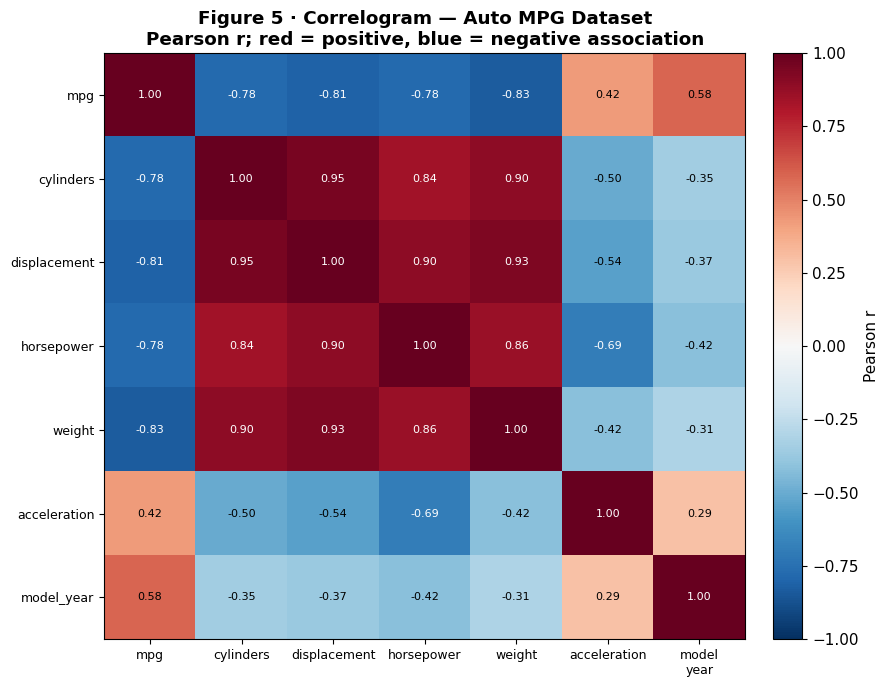

In [16]:
num_cols = ["mpg","cylinders","displacement","horsepower",
            "weight","acceleration","model_year"]
corr = mpg[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r", fraction=0.046, pad=0.04)

ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels([c.replace("_","\n") for c in num_cols], fontsize=9)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols, fontsize=9)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.values[i,j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(val)>0.6 else "black")

ax.set_title("Figure 5 · Correlogram — Auto MPG Dataset\n"
             "Pearson r; red = positive, blue = negative association",
             fontweight="bold")
plt.tight_layout()
plt.savefig("ch12_fig5_correlogram.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 12 · Figure 6 — 2-D Histogram and Hexbin

When scatter plots are too dense, we bin points into 2-D cells and
color each cell by count.

- **2-D histogram** bins into square cells (can show boundary artifacts).
- **Hexbin** bins into hexagonal cells—each hexagon has more uniform distances
  to its six neighbors than a square does, reducing directional bias.

**Tips dataset:** most bills cluster at $15–$20, with tips around $2–$4
(roughly 15% tip rate). A dense diagonal ridge is visible in both plots.

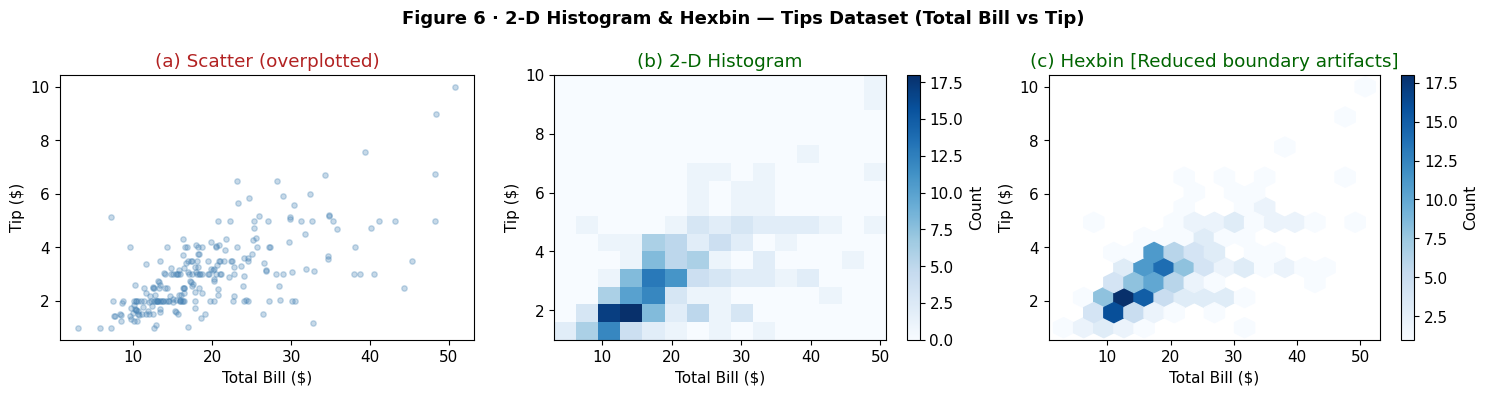

In [17]:
tips = sns.load_dataset("tips")
xh, yh = tips["total_bill"].values, tips["tip"].values

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Figure 6 · 2-D Histogram & Hexbin — Tips Dataset (Total Bill vs Tip)",
             fontsize=13, fontweight="bold")

a1.scatter(xh, yh, alpha=0.3, s=15, color="steelblue")
a1.set_title("(a) Scatter (overplotted)", color="firebrick")

h2d = a2.hist2d(xh, yh, bins=15, cmap="Blues")
plt.colorbar(h2d[3], ax=a2, label="Count")
a2.set_title("(b) 2-D Histogram", color="darkgreen")

hb = a3.hexbin(xh, yh, gridsize=15, cmap="Blues", mincnt=1)
plt.colorbar(hb, ax=a3, label="Count")
a3.set_title("(c) Hexbin [Reduced boundary artifacts]", color="darkgreen")

for ax in (a1, a2, a3):
    ax.set(xlabel="Total Bill ($)", ylabel="Tip ($)")

plt.tight_layout()
plt.savefig("ch12_fig6_hexbin.png", dpi=150, bbox_inches="tight")
plt.show()

## Chapter 12 · Key Findings

| Figure | Key insight |
|--------|-------------|
| 1 | Weight and mpg have r = −0.83; OLS slope ≈ −0.0077 mpg/lb, so a 1,000-lb heavier car loses ≈ 7.7 mpg. |
| 2 | Alpha + KDE contours (panel c) is the best overplotting fix; the bimodal X distribution becomes visible only there. |
| 3 | Bubble chart confirms the S-curve: life expectancy plateaus above ~$15K/capita even as GDP keeps rising. |
| 4 | Pair plot shows petal length vs petal width perfectly separates species; sepal features alone do not. |
| 5 | Correlogram reveals weight, displacement, cylinders are nearly redundant (r ≈ 0.9)—multicollinearity risk for regression. |
| 6 | Hexbin shows the tip cluster: most tables pay $15–$20 and tip $2–$3, with a near-linear relationship. |

# Chapter 13 · Visualizing Time Series and Other Functions of an Independent Variable

**Core idea:** time is a continuous, ordered variable—so lines connect observations
in a way bars or scatter cannot. Wilke covers:

- **Line charts** — the default for a single time series.
- **Multiple time series** — use color to distinguish groups; avoid "spaghetti."
- **Area charts** — fill under a line to emphasize cumulative magnitude.
- **Stacked area charts** — show composition over time (each layer sums to total).
- **Smoothed trend + confidence band** — separate long-term trend from noise.
- **Aspect ratio & banking to 45°** — how chart shape affects perceived slope.

In [18]:
# ── Synthetic monthly average temperature (Lincoln, NE style) ─────────────
month_params = {
    "Jan":(23.7,12),"Feb":(28.8,12),"Mar":(40.5,11),"Apr":(52.7,10),
    "May":(63.2,9), "Jun":(72.5,8), "Jul":(77.8,7), "Aug":(75.5,7),
    "Sep":(66.3,8), "Oct":(54.8,10),"Nov":(39.8,11),"Dec":(27.3,12),
}
month_order = list(month_params.keys())
rng2 = np.random.default_rng(0)
records = []
for m, (mean, std) in month_params.items():
    temps = rng2.normal(mean, std, 30)
    for t in temps:
        records.append({"Month": m, "Temp_F": t})
df_temp = pd.DataFrame(records)
df_temp["Month"] = pd.Categorical(df_temp["Month"], categories=month_order, ordered=True)
monthly_mean = df_temp.groupby("Month", observed=True)["Temp_F"].mean().values

# ── Synthetic 10-year daily time series ───────────────────────────────────
dates = pd.date_range("2014-01-01", periods=365*10, freq="D")
t     = np.arange(len(dates))
seasonal   = 25 * np.sin(2*np.pi*(t - 80)/365)
trend      = 0.003 * t
noise      = rng2.normal(0, 5, len(t))
temp_daily = 55 + seasonal + trend + noise
df_daily   = pd.DataFrame({"date": dates, "temp": temp_daily})
df_daily["year"]  = df_daily["date"].dt.year
df_daily["month"] = df_daily["date"].dt.month

# ── Synthetic multi-stock monthly returns ─────────────────────────────────
months_ts = pd.date_range("2018-01", periods=72, freq="MS")
np.random.seed(5)
def stock(mu, sigma):
    r = 1 + rng2.normal(mu, sigma, 72)/100
    return 100 * np.cumprod(r)
df_stocks = pd.DataFrame({
    "Date":   months_ts,
    "Tech":   stock(1.0, 5),
    "Energy": stock(0.3, 4),
    "Health": stock(0.6, 3),
    "Finance":stock(0.4, 4.5),
})

# ── Synthetic energy mix over time ────────────────────────────────────────
years_e = np.arange(2000, 2024)
coal    = 52  - 1.8*np.arange(24) + rng2.normal(0,1,24)
gas     = 18  + 0.6*np.arange(24) + rng2.normal(0,0.8,24)
nuclear = 20  - 0.2*np.arange(24) + rng2.normal(0,0.5,24)
wind    = 1   + 1.0*np.arange(24) + rng2.normal(0,0.5,24)
solar   = 0.2 + 0.6*np.arange(24)**1.2/10 + rng2.normal(0,0.3,24)
# normalise so each year sums to 100
stack_raw  = np.vstack([coal, gas, nuclear, wind, solar])
stack_pct  = stack_raw / stack_raw.sum(axis=0) * 100
df_energy  = pd.DataFrame(stack_pct.T, columns=["Coal","Gas","Nuclear","Wind","Solar"])
df_energy["Year"] = years_e

print("Time-series datasets ready.")

Time-series datasets ready.


## Ch 13 · Figure 1 — Basic Line Chart

A **line chart** connects ordered observations with a line. It is the canonical
tool for time series because the line implies continuity between measured points.

**Rule:** only draw lines for data where intermediate values make sense
(e.g., temperature between months). Never connect unrelated categories.

Here: monthly mean temperature in Lincoln, NE shows a smooth seasonal cycle.
The line lets us instantly see the warming trend from January through July,
and the symmetrical cooling back to December.

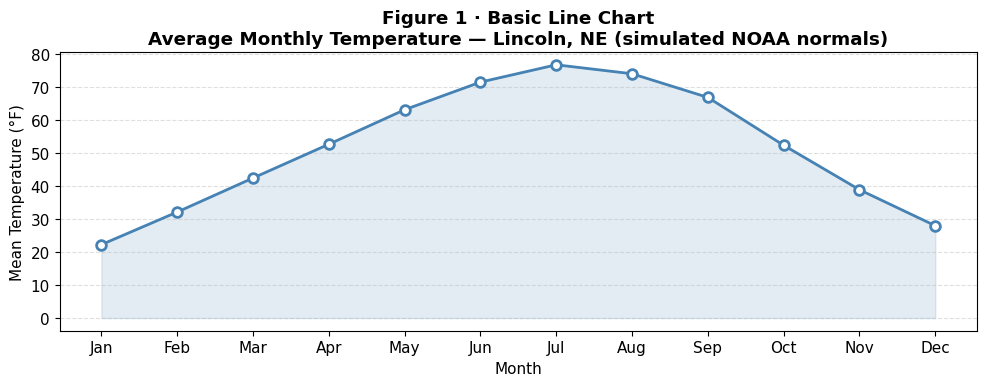

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_order, monthly_mean, marker="o", color="steelblue",
        linewidth=2, markersize=7, markerfacecolor="white", markeredgewidth=2)
ax.fill_between(month_order, monthly_mean, alpha=0.15, color="steelblue")
ax.set(xlabel="Month", ylabel="Mean Temperature (°F)")
ax.set_title("Figure 1 · Basic Line Chart\n"
             "Average Monthly Temperature — Lincoln, NE (simulated NOAA normals)",
             fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("ch13_fig1_line_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 13 · Figure 2 — Multiple Time Series

When comparing several time series, color is the primary encoding.
Wilke warns against **"spaghetti plots"**—too many overlapping lines
destroy legibility. The recommended fix is either:
1. Use fewer series (≤ 5), or
2. Use a "small multiples" / facet layout.

Here, four stock-sector indices (2018–2023) are shown together.
Technology (blue) dramatically outpaces the other sectors and shows
the clearest upward trend despite the 2020 COVID dip visible in all series.

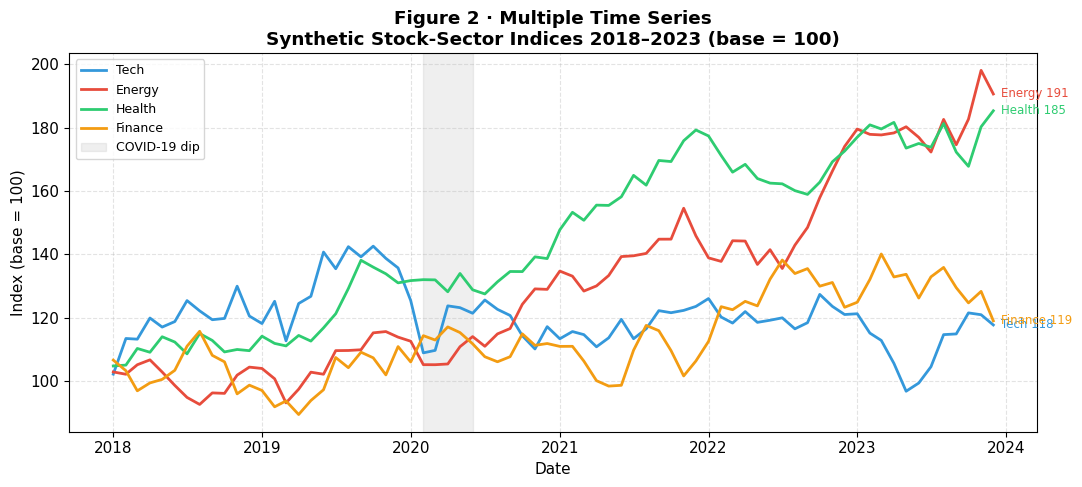

In [20]:
sector_colors = {"Tech":"#3498DB","Energy":"#E74C3C",
                 "Health":"#2ECC71","Finance":"#F39C12"}

fig, ax = plt.subplots(figsize=(11, 5))
for col, c in sector_colors.items():
    ax.plot(df_stocks["Date"], df_stocks[col],
            color=c, linewidth=2, label=col)
    # annotate end value
    ax.text(df_stocks["Date"].iloc[-1] + pd.Timedelta(days=20),
            df_stocks[col].iloc[-1], f"{col} {df_stocks[col].iloc[-1]:.0f}",
            va="center", fontsize=8.5, color=c)

ax.axvspan(pd.Timestamp("2020-02"), pd.Timestamp("2020-06"),
           alpha=0.12, color="gray", label="COVID-19 dip")
ax.set(xlabel="Date", ylabel="Index (base = 100)")
ax.set_title("Figure 2 · Multiple Time Series\n"
             "Synthetic Stock-Sector Indices 2018–2023 (base = 100)",
             fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("ch13_fig2_multi_line.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 13 · Figure 3 — Area Chart

An **area chart** fills the region between the line and the x-axis.
This emphasizes the *total accumulated value* rather than just the rate of change.

**When to use:** when the filled area has a meaningful interpretation
(e.g., total energy produced, total revenue, cumulative cases).

**When to avoid:** when comparing multiple series—overlapping fills create
visual confusion. Use a line chart instead.

Here, US daily temperatures over 10 years are plotted as a rolling 30-day mean.
The filled area makes the seasonal amplitude immediately apparent, and
the slight upward drift of the peaks signals the warming trend.

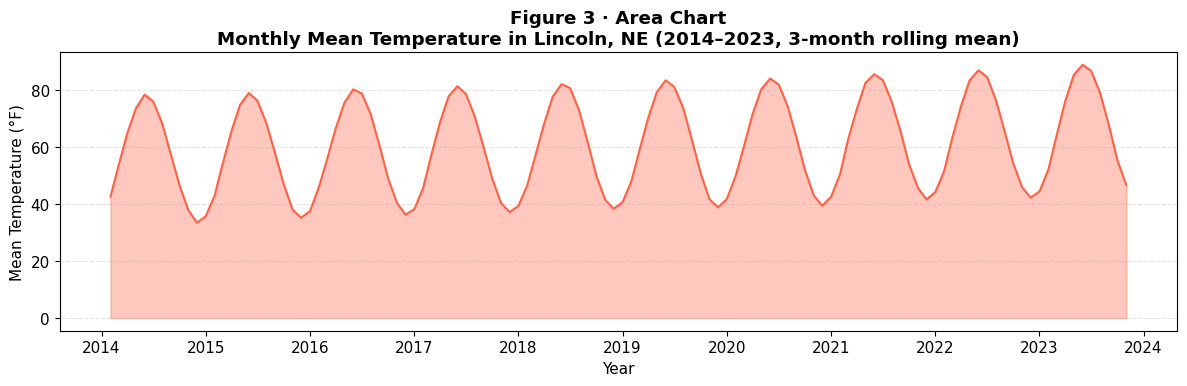

In [21]:
monthly_avg = df_daily.groupby(["year","month"])["temp"].mean().reset_index()
monthly_avg["date"] = pd.to_datetime(
    monthly_avg[["year","month"]].assign(day=1))
monthly_avg = monthly_avg.sort_values("date")

# Rolling 3-month smooth for display
monthly_avg["smooth"] = monthly_avg["temp"].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(monthly_avg["date"], monthly_avg["smooth"],
                alpha=0.35, color="tomato")
ax.plot(monthly_avg["date"], monthly_avg["smooth"],
        color="tomato", linewidth=1.5)
ax.set(xlabel="Year", ylabel="Mean Temperature (°F)")
ax.set_title("Figure 3 · Area Chart\n"
             "Monthly Mean Temperature in Lincoln, NE (2014–2023, 3-month rolling mean)",
             fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("ch13_fig3_area_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 13 · Figure 4 — Stacked Area Chart

A **stacked area chart** shows both the total and the composition over time.
Each layer represents one sub-category, and the top of the stack is the total.

**Use when:** individual components plus their sum are both meaningful.
**Avoid when:** many thin slices create "ribbon" confusion.

Here, the energy mix (% of total) from 2000–2023 shows a clear story:
Coal share collapses from ~52% to ~20%, while Wind and Solar grow from near-zero
to ~20% combined—a dramatic structural shift in 23 years.

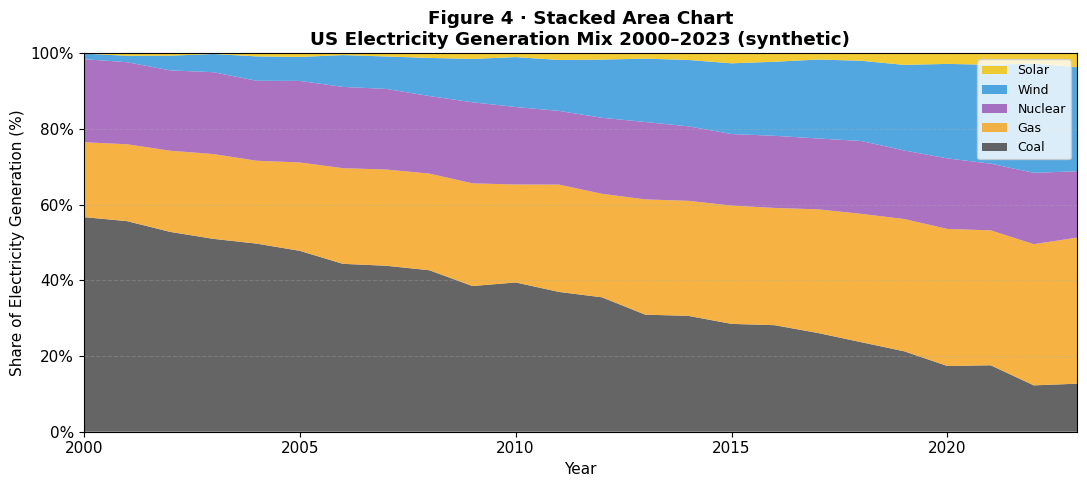

In [22]:
e_cols   = ["Coal","Gas","Nuclear","Wind","Solar"]
e_colors = ["#4A4A4A","#F5A623","#9B59B6","#3498DB","#F1C40F"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.stackplot(df_energy["Year"],
             [df_energy[c] for c in e_cols],
             labels=e_cols, colors=e_colors, alpha=0.85)
ax.set(xlim=(2000,2023), ylim=(0,100),
       xlabel="Year", ylabel="Share of Electricity Generation (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.set_title("Figure 4 · Stacked Area Chart\n"
             "US Electricity Generation Mix 2000–2023 (synthetic)",
             fontweight="bold")
ax.legend(loc="upper right", fontsize=9, reverse=True)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("ch13_fig4_stacked_area.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 13 · Figure 5 — Smoothed Trend with Confidence Band

Raw time series data is often noisy. A **rolling mean** (or LOESS smoother)
extracts the long-term trend. Adding a **confidence band** (rolling ± 1 SD)
communicates uncertainty around the smooth estimate.

Wilke emphasizes: show both the raw data *and* the smooth—hiding the raw data
suggests a false precision. Here we overlay the individual monthly means (dots)
with a 12-month rolling mean (line) and ± 1 SD band.

The warming trend of roughly +1°F per decade is visible as an upward drift
in the rolling mean.

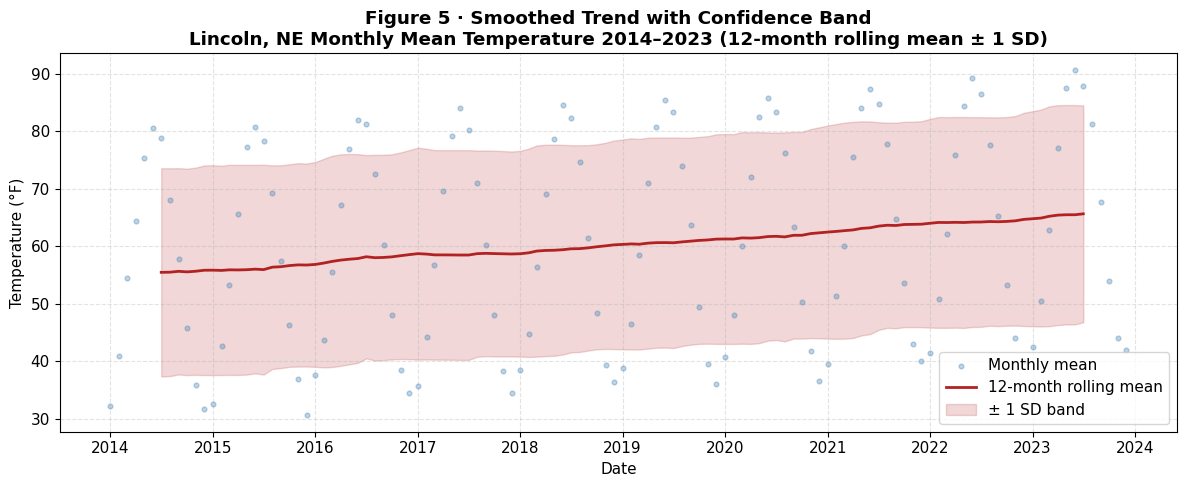

In [23]:
df_annual = df_daily.groupby(df_daily["date"].dt.to_period("M"))["temp"].agg(
    ["mean","std"]).reset_index()
df_annual["date"] = df_annual["date"].dt.to_timestamp()
df_annual["roll_mean"] = df_annual["mean"].rolling(12, center=True).mean()
df_annual["roll_std"]  = df_annual["mean"].rolling(12, center=True).std()

fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(df_annual["date"], df_annual["mean"],
           color="steelblue", alpha=0.35, s=12, zorder=2, label="Monthly mean")
ax.plot(df_annual["date"], df_annual["roll_mean"],
        color="firebrick", linewidth=2, zorder=3, label="12-month rolling mean")
ax.fill_between(df_annual["date"],
                df_annual["roll_mean"] - df_annual["roll_std"],
                df_annual["roll_mean"] + df_annual["roll_std"],
                color="firebrick", alpha=0.18, label="± 1 SD band")

ax.set(xlabel="Date", ylabel="Temperature (°F)")
ax.set_title("Figure 5 · Smoothed Trend with Confidence Band\n"
             "Lincoln, NE Monthly Mean Temperature 2014–2023 (12-month rolling mean ± 1 SD)",
             fontweight="bold")
ax.legend()
ax.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("ch13_fig5_smoothed_trend.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 13 · Figure 6 — Aspect Ratio and Banking to 45°

The **aspect ratio** of a line chart dramatically affects perceived slope.
Wilke (following Cleveland) recommends **"banking to 45°"**: choose the
aspect ratio so that the median absolute slope of the line segments is
approximately 45°—this maximizes slope discrimination.

- A **wide, short** chart compresses slopes → everything looks flat, trends are hidden.
- A **tall, narrow** chart exaggerates slopes → small changes look dramatic.
- The **banked** chart is calibrated so the eye perceives actual slope magnitudes.

The same seasonal temperature data is shown in all three aspect ratios.

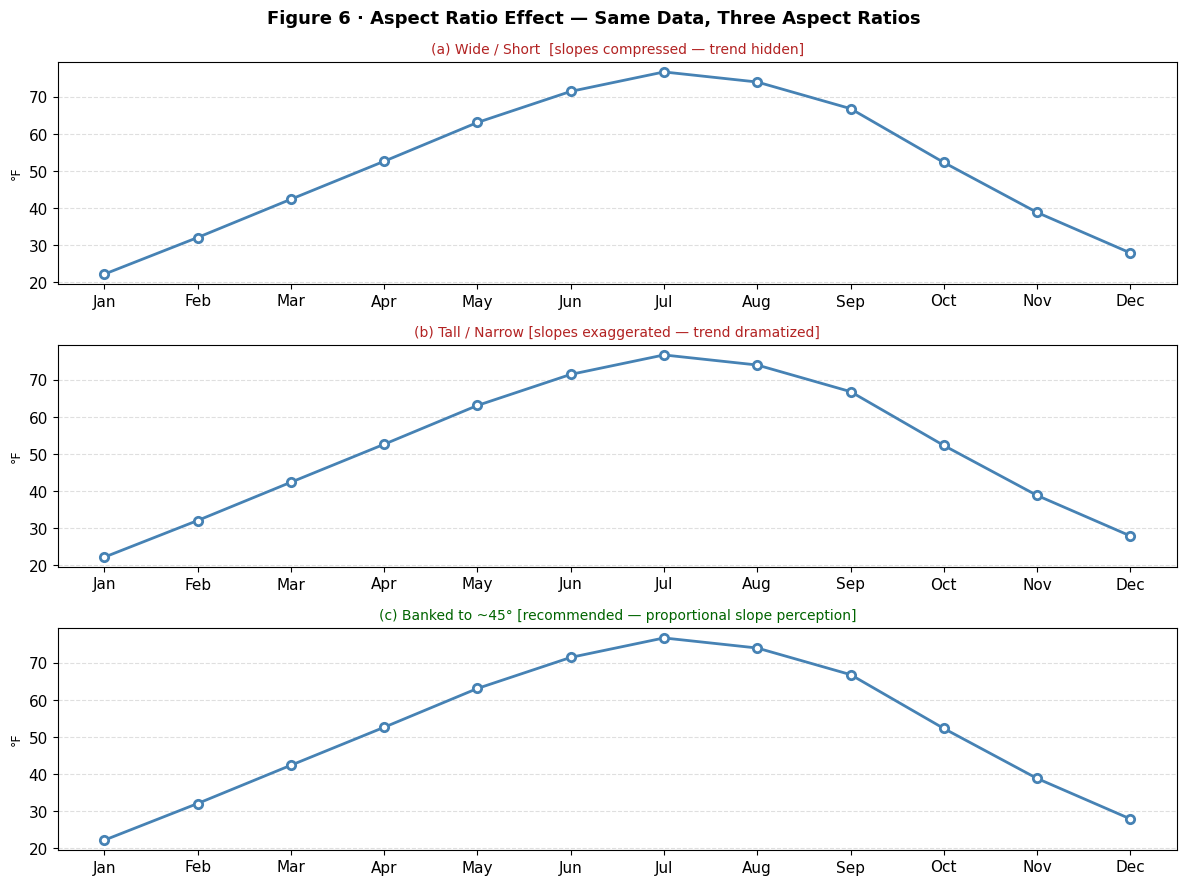

In [24]:
x_vals = np.arange(len(month_order))
y_vals = monthly_mean

fig, axes = plt.subplots(3, 1, figsize=(12, 9))
fig.suptitle("Figure 6 · Aspect Ratio Effect — Same Data, Three Aspect Ratios",
             fontsize=13, fontweight="bold")

configs = [
    ("(a) Wide / Short  [slopes compressed — trend hidden]", (12, 1.5), "firebrick"),
    ("(b) Tall / Narrow [slopes exaggerated — trend dramatized]", (3, 8), "firebrick"),
    ("(c) Banked to ~45° [recommended — proportional slope perception]", (10, 4), "darkgreen"),
]

for ax, (title, (fw, fh), tcol) in zip(axes, configs):
    ax.plot(month_order, y_vals, marker="o", color="steelblue",
            linewidth=2, markersize=6, markerfacecolor="white", markeredgewidth=2)
    ax.set_ylabel("°F", fontsize=9)
    ax.set_title(title, color=tcol, fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_xlim(-0.5, 11.5)

plt.tight_layout()
plt.savefig("ch13_fig6_aspect_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## Chapter 13 · Key Findings

| Figure | Key insight |
|--------|-------------|
| 1 | Line chart is the correct default for ordered time data; it implies continuity that a bar chart does not. |
| 2 | Multiple lines work up to ~5 series; the COVID dip (Feb–Jun 2020) is visible across all sectors but Tech recovered fastest. |
| 3 | Area chart highlights seasonal amplitude: summer months are ≈ 55°F warmer than winter months on average. |
| 4 | Stacked area reveals the energy transition: Coal share fell from 52% → 20% (2000–2023) while Wind + Solar grew from <2% → ~20%. |
| 5 | Smoothed trend + band separates the seasonal signal from the long-term +1°F/decade warming trend visible in the rolling mean. |
| 6 | Aspect ratio matters: banking to 45° (panel c) gives the most honest representation; wide/short charts can completely hide significant trends. |